In [85]:
import wandb
from ferminet.training_monitoring import wandb_login

wandb_login()


# Set your entity and project
entity = "parvagrw02-imperial-college-london"
project = "ferminet"
group_name = "F_sweep_final"

# Initialize the API
api = wandb.Api()

# Get all runs in a project filtered by group
runs = api.runs(
    path=f"{entity}/{project}",
    filters={"group": group_name}
)

# Example: print run names
for run in runs:
   history = run.history(samples=1000, keys=["mean_energy"])
   break

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\Parv\_netrc
wandb: WARNING Unable to load pandas, call history with pandas=False


In [90]:
def get_mean_last_n_samples(mean_energy_history, n_samples=10):
    return sum([i['mean_energy'] for i in mean_energy_history][-n_samples:])/n_samples

In [43]:
import json

In [91]:
# Example: print run names
mean_energies = []
distances = []
for run in runs:
   history = run.history(samples=10000,
                          keys=["mean_energy"], pandas=False)
   cfg = json.loads(run.config)
   distance = cfg['system']['value']['atomic_distance']
   mean_e = get_mean_last_n_samples(history)

   mean_energies.append(mean_e)
   distances.append(distance)

In [92]:
energies_sorted, distances_sorted = zip(*sorted(zip(mean_energies, distances), key=lambda x: x[1]))

In [70]:
import matplotlib.pyplot as plt

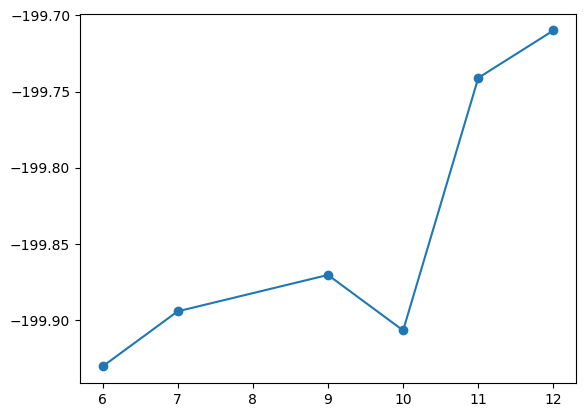

In [93]:
plt.plot(distances_sorted[:6], energies_sorted[:6], marker='o')
